In [24]:
import numpy as np

lte_folder_path = r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r1.bin"
wf_folder_path =  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r1.bin"

lte_raw_data = np.fromfile(lte_folder_path, dtype=np.float32)
wf_raw_data = np.fromfile(wf_folder_path, dtype=np.float32)

wf_iq_data = wf_raw_data.reshape(-1, 2)
wf_signal = wf_iq_data[:, 0] + 1j * wf_iq_data[:, 1]
print(wf_signal)
print(wf_signal.shape)

lte_iq_data = lte_raw_data.reshape(-1, 2,)
lte_signal = lte_iq_data[:, 0] + 1j * lte_iq_data[:, 1]
print(lte_signal)
print(lte_signal.shape)


[-0.00183111-0.00299081j  0.00042726-0.00396741j  0.00106815+0.0019837j
 ... -0.0028077 +0.00262459j -0.00024415+0.00109867j
 -0.00036622-0.0004883j ]
(1100000,)
[ 7.9348107e-04+6.1037004e-05j  4.5777753e-04-3.3570352e-04j
  1.5259252e-04+6.1037004e-05j ... -6.1037004e-05-6.7140703e-04j
  0.0000000e+00+9.1555507e-05j  1.2207401e-04+5.7985156e-04j]
(1100000,)


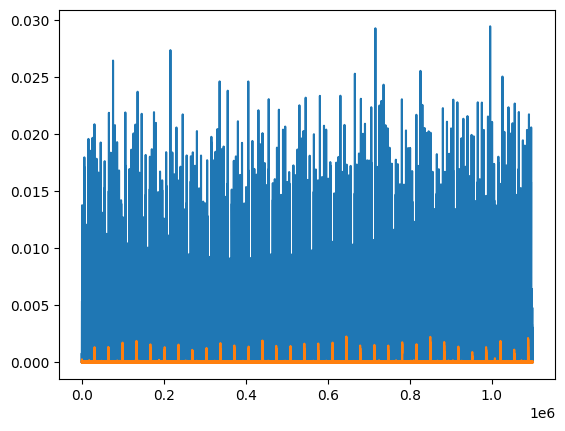

In [25]:
import matplotlib.pyplot as plt

lte_power = np.abs(lte_signal) ** 2
wf_power = np.abs(wf_signal) ** 2
plt.plot(lte_power)
plt.plot(wf_power)

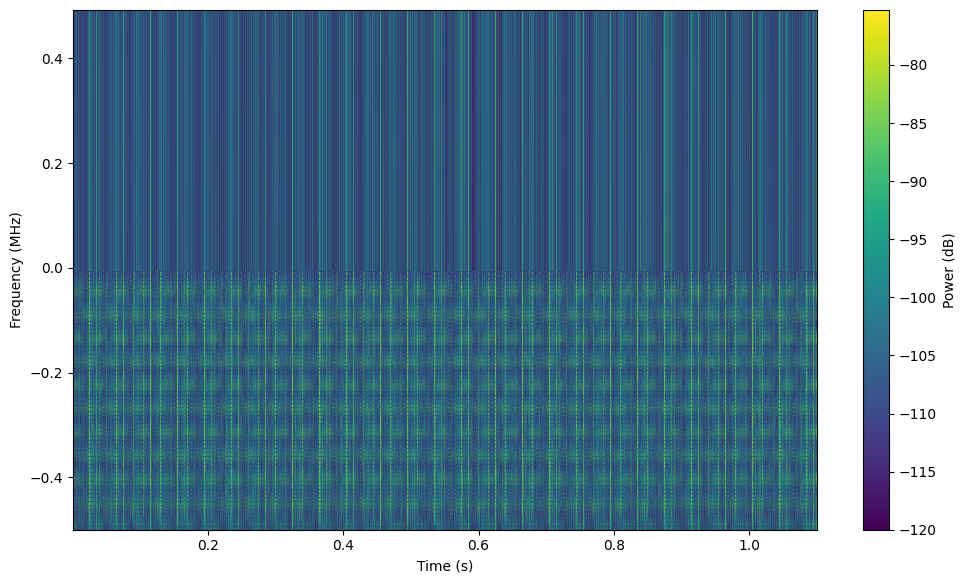

In [23]:
from scipy.signal import spectrogram

fs = 1e6   # 先隨便填(之後再調)

f, t, Sxx = spectrogram(lte_signal,
                        fs=fs,
                        nperseg=128,
                        noverlap=64,
                        return_onesided=False)

plt.figure(figsize=(12,6.75))
plt.pcolormesh(t, f/1e6, 10*np.log10(np.abs(Sxx)+1e-12), shading='gouraud')
plt.ylabel('Frequency (MHz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Power (dB)')
plt.show()

In [60]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random
import math
from scipy.signal import spectrogram

Import modules

In [61]:
folder = [r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r1.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r1.bin", 
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r1.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r2.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r2.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r2.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r3.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r3.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r3.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r4.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r4.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r4.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r5.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r5.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r5.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r6.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r6.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r6.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r7.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r7.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r7.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r8.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r8.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r8.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r9.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r9.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r9.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\dvbt_g30_rabot_f482MHz_r10.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\lte_g30_rabot_f806MHz_r10.bin",
          r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\rabot\wf_g76_rabot_f5240MHz_r10.bin"]

In [62]:
def load_data(path):
  data = np.fromfile(path, dtype=np.float32)
  # convert to I/Q data
  iq_data = data.reshape(-1, 2)
  signal = iq_data[:, 0] + 1j * iq_data[:, 1]
  # print(type(signal))
  # print(len(signal))
  return signal

# load_data(folder[0])

In [63]:
def sliding_windows(signal, window_size, stride):
  for start in range(0, len(signal) - window_size + 1, stride): # +1 是為了讓所有 window 放得下
    yield signal[start:start+window_size] # (100000,) and 41 個 (stride: 25000)

# signal = load_data(folder[0])
# count = 0
# for s in sliding_windows(signal, 100000, 25000):
#   print(s.shape)
#   count += 1

# print(count)

In [65]:
def compute_spectrogram_patch(signal, fs=1e6, nperseg=256, noverlap=128):
    f, t, Sxx = spectrogram(signal, fs=fs, nperseg=nperseg,
                            noverlap=noverlap, return_onesided=False)
    # convert to dB, crop or normalize as needed
    img = 10*np.log10(np.abs(Sxx)**2+1e-12)
    img_std = img.std()
    img_mean = img.mean()
    img = (img - img_mean) / (img_std + 1e-12)
    return img  # shape (freq_bins, time_bins)

In [66]:
# augmentations
def add_awgn(x, snr_db):
    # x: complex numpy 1D
    sig_p = np.mean(np.abs(x)**2)
    snr = 10**(snr_db/10.0)
    noise_p = sig_p / snr
    noise = (np.random.randn(*x.shape) + 1j*np.random.randn(*x.shape)) * np.sqrt(noise_p/2)
    return x + noise

def freq_shift(x, fs, shift_hz):
    # multiply by complex exponential to shift frequency
    n = np.arange(len(x))
    return x * np.exp(1j*2*np.pi*shift_hz*n/fs)

def time_shift(x, max_shift):
    # circular shift in samples
    s = random.randint(-max_shift, max_shift)
    return np.roll(x, s)

def amp_scale(x, low=0.6, high=1.4):
    scale = random.uniform(low, high)
    return x * scale

In [67]:
stride = 100000
def generate_dataset(path, label, window_size=100000, stride=100000, fs=1e6, n_arg=8):
  signal = load_data(path)
  patches = []
  label_map = {'dvbt': 0, 'lte': 1, 'wf': 2}
  for s in sliding_windows(signal, window_size, stride):
    patches.append((compute_spectrogram_patch(s, fs=fs), label_map[label]))

    for _ in range(n_arg):
      y = s.copy()
      # random augment chain
      if random.random()<0.7: y = add_awgn(y, snr_db=random.uniform(5,30))
      if random.random()<0.5: y = freq_shift(y, fs, shift_hz=random.uniform(-5000,5000))
      if random.random()<0.5: y = time_shift(y, max_shift=1000)
      if random.random()<0.5: y = amp_scale(y)
      img = compute_spectrogram_patch(y, fs)
      patches.append((img, label_map[label]))
  return patches

In [68]:
def data_to_torch(patches):
  x_list = [] # img
  y_list = [] # label

  for img, label in patches: 
    # print(img.shape) # (256, 780)
    x_list.append(img)
    y_list.append(label)

  # N = len(x_list)
  # 比較快 ******* 重要 ******
  x_list = np.stack(x_list, dtype=np.float32)
  # 加上 channel
  X = torch.from_numpy(x_list)
  Y = torch.tensor(y_list, dtype=torch.long)
  # X = X.reshape((N, 1, 256, 780)) 不好, 推薦 unsqueeze(1)
  X = X.unsqueeze(1)
  # print(X.shape)
  # print(Y.shape)
  return Y, X

patches = []

for i in range(len(folder)):
  if (i % 3) == 0:
    print(i)
    patches.extend(generate_dataset(folder[i], 'dvbt')) # (369, 2,))
  if ((i-1) % 3) == 0:
    patches.extend(generate_dataset(folder[i], 'lte')) # (369, 2,)
  if ((i-2) % 3) == 0:
    patches.extend(generate_dataset(folder[i], 'wf')) # (369, 2,)

Y, X = data_to_torch(patches)
print(Y.shape)
print(X.shape)

0
3
6
9
12
15
18
21
24
27
torch.Size([2970])
torch.Size([2970, 1, 256, 780])


In [69]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X, Y)

print(len(train_dataset))
for train, label in train_dataset:
  print(train.shape, label.item())

2970
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 

In [70]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.optim as optim
import torch.nn.functional as func

In [71]:
batch_size = 32
epochs = 10
lr = 1e-4
# transfer learning fc and layer 4
lr_fc = 3e-4
lr_layer4 = 5e-4
j = 2

In [72]:
torch.manual_seed(42) # 在程式最開頭加上這行

# 偵測有沒有 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的裝置: {device}")
# load models
model = resnet18(weights=ResNet18_Weights.DEFAULT)
# Fine tuning 前先換最後一層接口數
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, 3) # 作者最後一層就叫做 fc

# frozen some layers i.e. fc and layer 4
for para in model.parameters():
  # print(para.shape)
  para.requires_grad = False # 先都關掉

# 再打開要的
for para in model.layer4.parameters():
  para.requires_grad = True
for para in model.fc.parameters():
  para.requires_grad = True

# for para in model.parameters():
#   print(para.requires_grad)

model = model.to(device=device)

# 設定 optim
# optimizer = optim.SGD(model.parameters(), lr=lr)
optimizer = optim.Adam([{'params': model.layer4.parameters(), 'lr': lr_layer4, 'weight_decay':  5e-2},
                        {'params': model.fc.parameters(), 'lr': lr_fc, 'weight_decay': 1e-2}], lr=lr)

目前使用的裝置: cuda


In [73]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for i, train in enumerate(train_dataloader):
  print(train[0].shape) # torch.Size([32, 1, 256, 780])

torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size

In [74]:
print("Start training ...")
model.train()
criterion = torch.nn.CrossEntropyLoss()
log_file = open(f"resnet18_RF_train_run{j}_log.txt", "w", encoding="utf-8")

for epoch in range(epochs):
    epoch_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (batch_img, batch_label) in enumerate(train_dataloader):
        batch_img = batch_img.to(device)
        batch_label = batch_label.to(device)

        # 若你是 1-channel，最少改動：變 3-channel
        # batch_img = torch.nn.functional.interpolate(batch_img, size=(224,224), mode="bilinear", align_corners=False)
        batch_img = batch_img.repeat(1, 3, 1, 1)

        optimizer.zero_grad()
        prediction = model(batch_img)

        loss = criterion(prediction, batch_label)
        epoch_loss += loss.item() * batch_img.size(0)

        # 看正確率
        total += batch_label.size(0)
        pred = prediction.argmax(1)
        correct += (pred == batch_label).sum().item()

        loss.backward()
        optimizer.step()

    train_acc = correct / total
    avg_epoch_loss = epoch_loss / len(train_dataset)
    log_file.write(f"{avg_epoch_loss}\n")

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1}: loss {avg_epoch_loss:.4f}, acc {train_acc:.4f}")

log_file.close()
print("End training ...")

PATH = f"resnet18_RF_run{j}.pt"
torch.save(model.state_dict(), PATH)

Start training ...
epoch 1: loss 0.0443, acc 0.9852
epoch 5: loss 0.0269, acc 0.9946
epoch 10: loss 0.0210, acc 0.9960
End training ...


In [81]:
test_folder = [
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\dvbt_g30_merelbeke_f482MHz_r1.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\lte_g30_merelbeke_f806MHz_r1.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\wf_g30_merelbeke_f5180MHz_r1.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\dvbt_g30_merelbeke_f482MHz_r2.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\lte_g30_merelbeke_f806MHz_r2.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\wf_g30_merelbeke_f5180MHz_r2.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\dvbt_g30_merelbeke_f482MHz_r3.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\lte_g30_merelbeke_f806MHz_r3.bin",
  r"C:\Users\eric0\Desktop\ML\eric_env\project_2\data\Technology Recognition (LTE, Wi-Fi and DVB-T)\Technology Recognition (LTE, Wi-Fi and DVB-T)\merelbeke\wf_g30_merelbeke_f5180MHz_r3.bin"
]

In [82]:
def generate_test_dataset(path, label, window_size=100000, stride=stride, fs=1e6, n_arg=8):
  signal = load_data(path)
  patches = []
  label_map = {'dvbt': 0, 'lte': 1, 'wf': 2}
  for s in sliding_windows(signal, window_size, stride):
    img = compute_spectrogram_patch(s, fs=fs)
    img = np.flip(img, axis=0)
    patches.append((compute_spectrogram_patch(s, fs=fs), label_map[label]))

    for _ in range(n_arg):
      y = s.copy()
      # random augment chain
      if random.random()<0.7: y = add_awgn(y, snr_db=random.uniform(5,30))
      if random.random()<0.5: y = freq_shift(y, fs, shift_hz=random.uniform(-5000,5000))
      if random.random()<0.5: y = time_shift(y, max_shift=1000)
      if random.random()<0.5: y = amp_scale(y)
      img = compute_spectrogram_patch(y, fs)
      img = np.flip(img, axis=0)
      patches.append((img, label_map[label]))
  return patches

In [83]:
# 1. 先宣告一個空的 ResNet-18 (別忘了換頭！)
test_model = resnet18()
test_num_features = test_model.fc.in_features
test_model.fc = torch.nn.Linear(test_num_features, 3)

# 2. 把存好的 .pt 檔塞進去
test_model.load_state_dict(torch.load("resnet18_RF_run2.pt"))
test_model.to(device)
test_model.eval() # 進入評估模式
print("模型讀取完畢，隨時可以使用！")

# 3. 匯入 test folder ****** test 使用自己生成 dataset 的方式
patches = []

for i in range(len(test_folder)):
  if (i % 3) == 0:
    print(i)
    patches.extend(generate_test_dataset(folder[i], 'dvbt')) # (369, 2,))
  if ((i-1) % 3) == 0:
    patches.extend(generate_test_dataset(folder[i], 'lte')) # (369, 2,)
  if ((i-2) % 3) == 0:
    patches.extend(generate_test_dataset(folder[i], 'wf')) # (369, 2,)

Y, X = data_to_torch(patches)
print(Y.shape)
print(X.shape)

# 4. dataset and dataloader
test_dataset = TensorDataset(X, Y)

print(len(test_dataset))
for test, label in test_dataset:
  print(test.shape, label.item())

模型讀取完畢，隨時可以使用！
0
3
6
torch.Size([891])
torch.Size([891, 1, 256, 780])
891
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
torch.Size([1, 256, 780]) 0
to

In [84]:
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for i, test in enumerate(test_dataloader):
  print(test[0].shape) # torch.Size([32, 1, 256, 780])

torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([32, 1, 256, 780])
torch.Size([27, 1, 256, 780])


In [85]:
test_model.eval()
num_sample = 0
num_correct = 0

with torch.no_grad():
  for test_img, test_label in test_dataloader:
    test_img = test_img.to(device)
    test_label = test_label.to(device)
    test_img = test_img.repeat(1, 3, 1, 1)

    test_prediction = test_model(test_img)
    test_pred = test_prediction.argmax(1)
    num_correct += (test_pred == test_label).sum().item()
    num_sample += test_label.size(0)

test_acc = num_correct / num_sample
print("test accuracy:", test_acc)

test accuracy: 0.9955106621773289


In [ ]:
# print(f"Start training ...")
# model.train()
# criterion = torch.nn.CrossEntropyLoss()
# # 進入訓練
# # 用 log 紀錄訓練過程
# log_file = open(f"resnet18_RF_train_run{i}_log.txt", 'w')

# for epoch in range(epochs):

#   epoch_loss = 0.0
#   for batch_idx, (batch_img, batch_label) in enumerate(train_dataloader):

#     # ***** 把數據搬到 GPU，否則會跟 model 的位置對不上 *****
#     batch_img = batch_img.to(device)
#     batch_label = batch_label.to(device)

#     # 在 Backward 之前記得清空舊的梯度 (這很重要！)
#     optimizer.zero_grad()
#     # forward pass
#     prediction = model(batch_img)

#     # 為了要讓 cross entropy 更穩定 (loss 穩定)
#     loss = criterion(prediction, batch_label)
#     epoch_loss += loss.item()
    
#     loss.backward()
#     # 更新權重
#     optimizer.step()
  
#   avg_epoch_loss = epoch_loss / len(train_dataloader)
#   log_content = f"{avg_epoch_loss}\n"
#   # 寫入 log.txt
#   log_file.write(log_content)
  
#   if (epoch + 1) % 5 == 0 or epoch == 0:
#     print(avg_epoch_loss)

# log_file.close() # 訓練完關閉檔案
# print(f"End training ...")

# # ***** 存 pt 檔 *****
# # 設定存檔路徑
# PATH = f"resnet18_RF_run{i}.pt"
# torch.save(model.state_dict(), PATH)